# APPROCHE A — Sign Language Production

**Encodeur :** T5-small fine-tuné (Nafissa)

**Décodeur :** Transformer Autorégressif (Sirine)

**Dataset :** How2Sign (ASL) — 31,046 phrases

**Métrique :** MPJPE + DTW

In [ ]:

!git clone https://github.com/sarrazer24/sign-language-production.git

2 .Config

In [ ]:

import torch
import torch.nn as nn
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import T5EncoderModel, T5Tokenizer

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
POSE_DIM   = 453   # 151 keypoints × 3 (x,y,z) 
MAX_FRAMES = 500
DATA_PATH  = "/kaggle/input/datasets/sarraverse/how2signdataset"

print(f" Device   : {device}")
print(f" POSE_DIM : {POSE_DIM}  (151 kp × 3D)")

 Device   : cuda
 POSE_DIM : 453  (151 kp × 3D)


3 .Dataset

In [ ]:

stats = torch.load(
    '/kaggle/working/sign-language-production/'
    'phase1_text_to_pose/data/stats.pt'
)

class How2SignDataset(Dataset):
    def __init__(self, split, data_path, stats=None, max_frames=500):
        self.max_frames = max_frames
        self.pose_dim   = POSE_DIM

        with open(f"{data_path}/{split}.text", 'r') as f:
            self.texts = [l.strip() for l in f.readlines()]

        with open(f"{data_path}/{split}.skels", 'r') as f:
            self.skels = [l.strip() for l in f.readlines()]

        min_len    = min(len(self.texts), len(self.skels))
        self.texts = self.texts[:min_len]
        self.skels = self.skels[:min_len]

        #  flatten (151,3) → (453,)
        if stats is not None:
            self.mean = stats['mean'].numpy().flatten()
            self.std  = stats['std'].numpy().flatten()
        else:
            self.mean = None
            self.std  = None

        print(f" {split}: {len(self.texts)} phrases | POSE_DIM={self.pose_dim}")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text   = self.texts[idx]
        values = np.array(
            list(map(float, self.skels[idx].split())),
            dtype=np.float32
        )

        # reshape → (T, 453)
        T     = len(values) // self.pose_dim
        poses = values[:T * self.pose_dim].reshape(T, self.pose_dim)

        # truncation
        if T > self.max_frames:
            poses = poses[:self.max_frames]
            T     = self.max_frames

        # normalisation 
        if self.mean is not None:
            poses = (poses - self.mean) / (self.std + 1e-8)

        return {
            "text"  : text,
            "poses" : torch.tensor(poses, dtype=torch.float32),
            "length": T
        }


def collate_fn(batch):
    texts    = [b["text"]   for b in batch]
    lengths  = [b["length"] for b in batch]
    max_T    = max(lengths)
    pose_dim = batch[0]["poses"].shape[-1]

    poses_padded = torch.zeros(len(batch), max_T, pose_dim)
    pose_mask    = torch.zeros(len(batch), max_T)

    for i, b in enumerate(batch):
        T = b["length"]
        poses_padded[i, :T] = b["poses"]
        pose_mask[i,    :T] = 1.0

    return {
        "texts"    : texts,
        "poses"    : poses_padded,
        "pose_mask": pose_mask,
        "lengths"  : torch.tensor(lengths)
    }

4 .DataLoader

In [ ]:

train_ds = How2SignDataset('train', DATA_PATH, stats=stats, max_frames=MAX_FRAMES)
dev_ds   = How2SignDataset('dev',   DATA_PATH, stats=stats, max_frames=MAX_FRAMES)

train_loader = DataLoader(
    train_ds, batch_size=16,
    shuffle=True,  collate_fn=collate_fn, num_workers=2
)
dev_loader = DataLoader(
    dev_ds, batch_size=16,
    shuffle=False, collate_fn=collate_fn, num_workers=2
)

batch = next(iter(train_loader))
print(f" poses shape  : {batch['poses'].shape}")
# doit être (16, T, 453)
print(f" mask shape   : {batch['pose_mask'].shape}")
print(f" lengths      : {batch['lengths'][:5].tolist()}")
print(f" texte        : {batch['texts'][0][:60]}")

 train: 31046 phrases | POSE_DIM=453
 dev: 1739 phrases | POSE_DIM=453
 poses shape  : torch.Size([16, 190, 453])
 mask shape   : torch.Size([16, 190])
 lengths      : [92, 31, 26, 28, 68]
 texte        : "You can take it and put it in there like that, little band 


5 .T5 Encoder 

In [ ]:

class T5Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.tokenizer = T5Tokenizer.from_pretrained("t5-small")
        self.encoder   = T5EncoderModel.from_pretrained("t5-small")

        #  geler tout
        for param in self.encoder.parameters():
            param.requires_grad = False

        #  ouvrir les 2 dernières couches
        for param in self.encoder.encoder.block[-2:].parameters():
            param.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f" T5Encoder | trainable: {trainable:,} / {total:,}")

    def forward(self, texts, device):
        tokens = self.tokenizer(
            texts,
            return_tensors = "pt",
            padding        = True,
            truncation     = True,
            max_length     = 128
        ).to(device)

        out = self.encoder(
            input_ids      = tokens["input_ids"],
            attention_mask = tokens["attention_mask"]
        )
        return out.last_hidden_state  # (B, T_text, 512)

6 .Pose Decoder 

In [ ]:

class PoseDecoder(nn.Module):
    def __init__(self, pose_dim=POSE_DIM, d_model=256):
        super().__init__()

        self.pose_embed  = nn.Linear(pose_dim, d_model)
        self.memory_proj = nn.Linear(512, d_model)

        dec_layer = nn.TransformerDecoderLayer(
            d_model         = d_model,
            nhead           = 8,
            dim_feedforward = 1024,
            dropout         = 0.1,
            batch_first     = True
        )
        self.decoder    = nn.TransformerDecoder(dec_layer, num_layers=4)
        self.projection = nn.Linear(d_model, pose_dim)

        print(f" PoseDecoder | pose_dim={pose_dim} | d_model={d_model}")

    def forward(self, poses, memory, pose_mask):
        B, T, _ = poses.shape

        # Causal mask — ne voit pas le futur
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=poses.device
        )
        # Padding mask
        pad_mask = ~pose_mask.bool()

        # Projections
        memory = self.memory_proj(memory)  # 512 → 256
        x      = self.pose_embed(poses)    # pose_dim → 256

        out = self.decoder(
            tgt                  = x,
            memory               = memory,
            tgt_mask             = causal_mask,
            tgt_key_padding_mask = pad_mask
        )
        return self.projection(out)  # 256 → pose_dim

7 .Loss + SignModel + Test

In [ ]:

def scale_adjusted_loss(pred, target, mask, lengths=None):
    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)
    loss = loss * mask.float()
    loss = loss.sum() / (mask.float().sum() + 1e-8)
    return loss

class SignModel(nn.Module):
    def __init__(self, pose_dim=POSE_DIM):
        super().__init__()
        self.encoder = T5Encoder()
        self.decoder = PoseDecoder(pose_dim=pose_dim)

    def forward(self, texts, poses, pose_mask, device):
        memory = self.encoder(texts, device)
        pred   = self.decoder(poses, memory, pose_mask)
        return pred

# ── test complet ──
model = SignModel(pose_dim=POSE_DIM).to(device)
pred  = model(
    texts     = batch['texts'],
    poses     = batch['poses'].to(device),
    pose_mask = batch['pose_mask'].to(device),
    device    = device
)
loss = scale_adjusted_loss(
    pred,
    batch['poses'].to(device),
    batch['pose_mask'].to(device)
)
print(f" SignModel OK!")
print(f"   pred shape : {pred.shape}")
print(f"   loss       : {loss.item():.6f}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

 T5Encoder | trainable: 6,293,504 / 35,330,816
 PoseDecoder | pose_dim=453 | d_model=256
 SignModel OK!
   pred shape : torch.Size([16, 190, 453])
   loss       : 1.234353


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


8 .Training Loop

In [ ]:

EPOCHS    = 50
LR        = 1e-4
SAVE_PATH = "/kaggle/working/best_model.pt"

optimizer     = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

for epoch in range(EPOCHS):
    # ── TRAIN ──
    model.train()
    total_train = 0.0
    for b in train_loader:
        optimizer.zero_grad()
        pred = model(
            texts     = b['texts'],
            poses     = b['poses'].to(device),
            pose_mask = b['pose_mask'].to(device),
            device    = device
        )
        loss = scale_adjusted_loss(
            pred,
            b['poses'].to(device),
            b['pose_mask'].to(device)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_train += loss.item()
    avg_train = total_train / len(train_loader)

    # ── VALIDATION ──
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for b in dev_loader:
            pred = model(
                texts     = b['texts'],
                poses     = b['poses'].to(device),
                pose_mask = b['pose_mask'].to(device),
                device    = device
            )
            loss = scale_adjusted_loss(
                pred,
                b['poses'].to(device),
                b['pose_mask'].to(device)
            )
            total_val += loss.item()
    avg_val = total_val / len(dev_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"    Checkpoint! Val: {avg_val:.4f}")

    scheduler.step()

print(f"\n Terminé! Meilleure Val Loss: {best_val_loss:.4f}")


Epoch 01/50 | Train: 0.1183 | Val: 0.0288
    Checkpoint! Val: 0.0288
Epoch 02/50 | Train: 0.0261 | Val: 0.0156
    Checkpoint! Val: 0.0156
Epoch 03/50 | Train: 0.0165 | Val: 0.0114
    Checkpoint! Val: 0.0114
Epoch 04/50 | Train: 0.0117 | Val: 0.0115
Epoch 05/50 | Train: 0.0092 | Val: 0.0083
    Checkpoint! Val: 0.0083
Epoch 06/50 | Train: 0.0073 | Val: 0.0057
    Checkpoint! Val: 0.0057
Epoch 07/50 | Train: 0.0064 | Val: 0.0053
    Checkpoint! Val: 0.0053
Epoch 08/50 | Train: 0.0052 | Val: 0.0047
    Checkpoint! Val: 0.0047
Epoch 09/50 | Train: 0.0047 | Val: 0.0041
    Checkpoint! Val: 0.0041
Epoch 10/50 | Train: 0.0042 | Val: 0.0040
    Checkpoint! Val: 0.0040
Epoch 11/50 | Train: 0.0037 | Val: 0.0034
    Checkpoint! Val: 0.0034
Epoch 12/50 | Train: 0.0034 | Val: 0.0034
Epoch 13/50 | Train: 0.0032 | Val: 0.0040
Epoch 14/50 | Train: 0.0029 | Val: 0.0024
    Checkpoint! Val: 0.0024
Epoch 15/50 | Train: 0.0026 | Val: 0.0025
Epoch 16/50 | Train: 0.0025 | Val: 0.0064
Epoch 17/50 | Train:

9 .Evaluation MPJPE

In [ ]:

model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

all_mpjpe = []

with torch.no_grad():
    for b in dev_loader:
        poses     = b['poses'].to(device)
        pose_mask = b['pose_mask'].to(device)

        pred = model(
            texts     = b['texts'],
            poses     = poses,
            pose_mask = pose_mask,
            device    = device
        )

        # MPJPE — reshape (B, T, 453) → (B, T, 151, 3)
        B, T, _ = pred.shape
        pred_3d   = pred.reshape(B, T, 151, 3)
        target_3d = poses.reshape(B, T, 151, 3)
        mask_flat = pose_mask.bool()

        # distance euclidienne par keypoint
        dist  = torch.norm(pred_3d - target_3d, dim=-1)  # (B,T,151)
        dist  = dist[mask_flat]                           # frames réelles
        mpjpe = dist.mean().item()
        all_mpjpe.append(mpjpe)

final_mpjpe = np.mean(all_mpjpe)
print(f" MPJPE final : {final_mpjpe:.4f}")

 MPJPE final : 0.0487


10 .DTW + Visualisation

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import cdist

# ── DTW function ──
def dtw_distance(seq1, seq2):
    """
    seq1: (T1, D)
    seq2: (T2, D)
    returns: DTW distance (float)
    """
    T1, D = seq1.shape
    T2    = seq2.shape[0]

    cost = cdist(seq1, seq2, metric='euclidean')  # (T1, T2)


    dtw = np.full((T1+1, T2+1), np.inf)
    dtw[0, 0] = 0.0

    for i in range(1, T1+1):
        for j in range(1, T2+1):
            dtw[i,j] = cost[i-1, j-1] + min(
                dtw[i-1, j  ],   # insertion
                dtw[i,   j-1],   # deletion
                dtw[i-1, j-1]    # match
            )
    return dtw[T1, T2] / (T1 + T2)

# ── DTW sur dev set ──
print(" Calcul DTW sur dev set...")
all_dtw  = []
examples = [] 

model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

with torch.no_grad():
    for b_idx, b in enumerate(dev_loader):
        poses     = b['poses'].to(device)
        pose_mask = b['pose_mask'].to(device)

        pred = model(
            texts     = b['texts'],
            poses     = poses,
            pose_mask = pose_mask,
            device    = device
        )

        pred_np   = pred.cpu().numpy()
        target_np = poses.cpu().numpy()
        mask_np   = pose_mask.cpu().numpy().astype(bool)
        lengths   = b['lengths'].numpy()

        for i in range(len(b['texts'])):
            T = lengths[i]
            p = pred_np[i,   :T, :]  # (T, 453)
            t = target_np[i, :T, :]  # (T, 453)

            d = dtw_distance(p, t)
            all_dtw.append(d)

       
            if len(examples) < 3:
                examples.append({
                    'text'  : b['texts'][i],
                    'pred'  : p,
                    'target': t,
                    'dtw'   : d,
                    'T'     : T
                })

final_dtw = np.mean(all_dtw)
print(f" DTW final : {final_dtw:.4f}")

 Calcul DTW sur dev set...
 DTW final : 0.3420


11 .Training curve

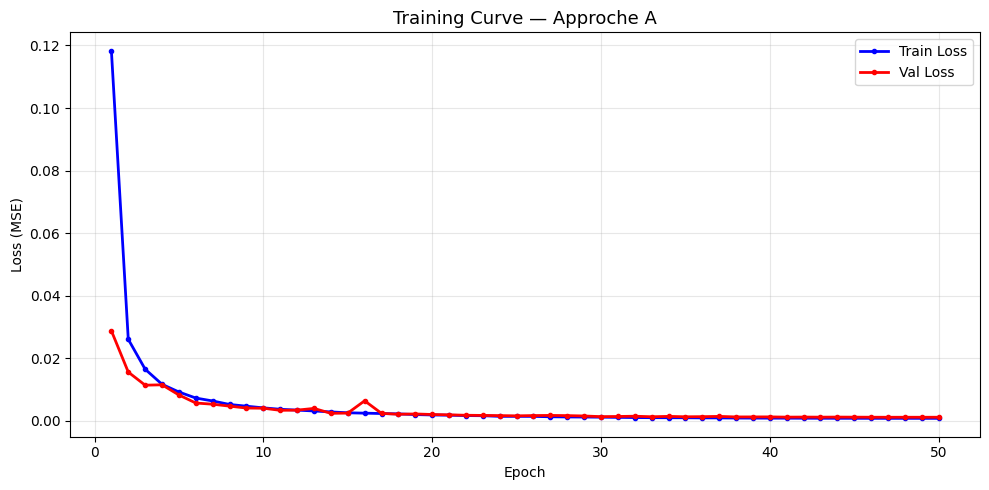

 Sauvegardé: /kaggle/working/training_curve.png


In [14]:
# ── Plot 3: Training curve ──
fig, ax = plt.subplots(figsize=(10, 5))

epochs = range(1, len(train_losses)+1)
ax.plot(epochs, train_losses, 'b-o',
        markersize=3, linewidth=2, label='Train Loss')
ax.plot(epochs, val_losses,   'r-o',
        markersize=3, linewidth=2, label='Val Loss')

ax.set_title('Training Curve — Approche A', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curve.png', dpi=150)
plt.show()
print(" Sauvegardé: /kaggle/working/training_curve.png")

In [15]:
import pandas as pd
os.makedirs('/kaggle/working/experiments', exist_ok=True)

results = pd.DataFrame({
    'approach'      : ['A'],
    'model'         : ['T5-small + TransformerDecoder'],
    'MPJPE'         : [round(final_mpjpe, 4)],
    'DTW'           : [round(final_dtw,   4)],
    'best_val_loss' : [round(best_val_loss, 4)],
    'epochs'        : [len(train_losses)],
    'batch_size'    : [16],
    'lr'            : [LR],
    'dropout'       : [0.1],
    'd_model'       : [256],
})

results.to_csv('/kaggle/working/experiments/results_A.csv', index=False)
print(results.to_string(index=False))
print("\n Sauvegardé: experiments/results_A.csv")

approach                         model  MPJPE   DTW  best_val_loss  epochs  batch_size     lr  dropout  d_model
       A T5-small + TransformerDecoder 0.0487 0.342         0.0011      50          16 0.0001      0.1      256

 Sauvegardé: experiments/results_A.csv
